# Coronagraph Optimization as a Linear Program
The bulk of amplitude-apodized coronagraph design comes from framing the apodized pupil lyot coronagraph (APLC) problem as a linear program. Because every propagation in a standard APLC is linear, the dark hole electric field is an affine function of the apodizer vector $x$. Said mathematically,

$$E_{dark hole} = Ax + b,$$

Where $E_dh$ is a vector of length $M$, $x$ and $b$ are vectors of length $N$, and $A$ is a matrix of shape $M \times N$. Constrained optimization can be achieved by maximizing throughput subject to the following box constraints:

> $|Re\{E \}| \leq \sqrt{C_{target}}$ for $x \in [0, 1]$

> $|Im\{E \}| \leq \sqrt{C_{target}}$ for $x \in [0, 1]$

Where this differs from the algorithmic differentiation method of coronagraph design is _memory_ and _convergence_. The $A$ matrix is dense, and can require gigabytes of memory to store to get started with the optimization. This procedure also finds a globally optimal solution, rather than the inherent "local" minimization accomplished using algorithmic differentiation.

In this explanation, we will walk you through how to use `dygdug` to set up an optimization problem using `scipy`'s HiGHS solver for linear programs, and show how we implemented it in `dygdug` to extend the utility to GPUs.

## Instrument setup
We begin by setting up a simple lyot coronagraph

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from time import perf_counter

from prysm.propagation import prepare_executor

from dygdug.masks import Pupil, FPM, ImgSamplingSpec, annular_mask, knife_edge_mask
from dygdug.coropt import VariablePupil
from dygdug.models import Coronagraph


# Define instrument parameters
circumscribed_diameter = 10.95e3
Npup = 256
Nfoc = 128
wvl = 1.0  # microns
fno = 13.66
iwa = 3
owa = 5
efl = fno * circumscribed_diameter
lamD = wvl / circumscribed_diameter * efl
px_per_lamD = 4  # the "oversampling"

In [17]:
# Variable (amplitude-apodized) entrance pupil
pupil = VariablePupil.annular(
    Dpup=circumscribed_diameter,
    Npup=Npup,
    inner_radius=0.1 * circumscribed_diameter / 2,
    outer_radius=1.0 * circumscribed_diameter / 2,
    mode="amplitude"
)

executor = prepare_executor(
    pupil_dx=circumscribed_diameter / Npup,
    pupil_samples=Npup,
    focal_dx=lamD / px_per_lamD,
    focal_samples=Nfoc,
    wavelength=wvl,
    efl=efl,
    focal_shift=(0, 0),
    kind="mdft",
)

fpm = FPM.annular(
    N=Nfoc,
    lamD=lamD,
    px_per_lamD=px_per_lamD,
    inner_radius=3,
    outer_radius=8,
)

lyot = Pupil.annular(
    Dpup=circumscribed_diameter,
    Npup=Npup,
    inner_radius=0.1 * circumscribed_diameter / 2,
    outer_radius=0.8 * circumscribed_diameter / 2,
)

coro = Coronagraph(pupil=pupil, fpm=fpm, lyot_stop=lyot, executor=executor)

## Optimization feasibility
Before conducting the optimization, an important check is to understand the set of the problem. For $M$ dark-hole pixels there are $4M$ inequality rows to account for the electric field constraints. For a feasible convergence, you want

$$N \gg 4M$$

In other words, you want many more apodizer pixels than you have electric field constraints.

In [18]:
iss = ImgSamplingSpec(Nfoc, px_per_lamD, lamD=lamD)
dark_hole = annular_mask(iss, iwa=iwa, owa=owa, theta_min=-90, theta_max=90)

dh_idx = np.flatnonzero(np.asarray(dark_hole).astype(bool).ravel())
pup_idx = pupil._mask_idx
n = pupil.n_params  # optimizable pupil pixels
m = dh_idx.size     # constrained dark-hole pixels

contrast_req = 1e-8

print(f"n = {n} pupil pixels, m = {m} dark-hole pixels -> 4m = {4*m} constraint rows")
print(f"n / 4m = {n / (4*m):.1f}  (want >> 1)")

n = 50920 pupil pixels, m = 584 dark-hole pixels -> 4m = 2336 constraint rows
n / 4m = 21.8  (want >> 1)


## Constructing the affine transform
The `coronagraph.reverse` method that returns the adjoint of the forward model yields the method required to seed the propagation. We apply a unit impluse to a dark hole pixel and store the gradient at each row of $A$. This builds the $A$ matrix in $M$ reverse propagations (which cost $\approx 2$ forward propagations).

The offset $b$ is computed from any samples in the pupil without unit or zero transmission that are not optimized. In this example, that arises from anti-aliased pixels on the array.

Note that the construction of the $A$ matrix can be accelerated by GPUs, the user must `set_backend_to_cupy` and then ensure the resulting array is copied into a `numpy` array after. For simplicity, we construct the entire model on an AMD Ryzen 7 9800X and store the matrix in memory.

In [19]:
from tqdm import tqdm
t0 = perf_counter()
A = np.empty((m, n), dtype=complex)
Ebar = np.zeros((Nfoc, Nfoc), dtype=complex)
for k, i in tqdm(enumerate(dh_idx)):
    Ebar.ravel()[i] = 1.0
    coro.reverse(Ebar, wvl, include_fpm=True)
    A[k] = np.conj(coro.adjoint_at_entrance_pupil.ravel()[pup_idx])
    Ebar.ravel()[i] = 0.0

# Return propagation time
print(f"Jacobian ({m} adjoint propagations): {perf_counter()-t0:.1f} s, "
      f"{A.nbytes/1e9:.0f} MB")

# Offset from the frozen (anti-aliased rim) pixels: the field with x = 0.
pupil.update(np.zeros(n))
b = coro.forward(wvl, include_fpm=True).ravel()[dh_idx].copy()

# Contrast normalization: direct (no-FPM) peak of the open pupil.
pupil.update(np.ones(n))
norm = float(np.max(np.abs(coro.forward(wvl, include_fpm=False)) ** 2))


584it [00:01, 525.15it/s]

Jacobian (584 adjoint propagations): 1.1 s, 0 MB


We can then test the affine model against the real propagator to ensure that the constructed linearization is correct

In [20]:
# Verify E_dh = A x + b against the real propagator.
rng = np.random.default_rng(0)
x_test = rng.uniform(0, 1, n)
pupil.update(x_test)
E_ref = coro.forward(wvl, include_fpm=True).ravel()[dh_idx]
err = np.max(np.abs(A @ x_test + b - E_ref)) / np.max(np.abs(E_ref))
print(f"affine model max relative error: {err:.1e}")
assert err < 1e-12, "affine model does not match the propagator"


affine model max relative error: 4.6e-15


Before conducting the solve, we can provide a final check that the design can be binary at the given contrast. For a given pixel in the apodizer, a change from 0 to 1 will alter the focal plane by the associated column in the Jacobian, $A$. We refer to this as the _field quantum_. A binary APLC creates the dark hole out of a selection of these quanta, so the amplitude budget $s = \sqrt{C_{target} / 2} must be several times this field quantum.

In [21]:
s_req = np.sqrt(contrast_req / 2)
quantum = np.abs(A) / np.sqrt(norm)  # per-pixel amplitude quantum, normalized

print(f"amplitude budget s: {s_req:.1e}")
print(f"pixel field quantum: max {quantum.max():.1e}, median {np.median(quantum):.1e}")
print(f"s / max quantum: {s_req / quantum.max():.1f}  (want >~ 3)")

amplitude budget s: 7.1e-05
pixel field quantum: max 3.9e-05, median 1.9e-05
s / max quantum: 1.8  (want >~ 3)


## Assemble and solve the linear program
Normalizing by the direct image peak, we construct the bounds for the $A$ and $b$ parts of the affine transform that maximize throughput. Here, the throughput maximization is achieved by providing `linprog` with a vector of `-1`. This turns the minimization into a maximization of the pixel values, which is a proxy for core throughput.

In [22]:
from scipy.optimize import linprog

rn = 1 / np.sqrt(norm)
M, boff = A * rn, b * rn
A_ub = np.vstack([M.real, -M.real, M.imag, -M.imag])
b_ub = s_req + np.concatenate([-boff.real, boff.real, -boff.imag, boff.imag])
print(f"LP: {A_ub.shape[0]} rows x {A_ub.shape[1]} cols ({A_ub.nbytes/1e6:.0f} MB)")

t0 = perf_counter()
res = linprog(-np.ones(n), A_ub=A_ub, b_ub=b_ub, bounds=(0, 1), method="highs")
print(f"solve: {perf_counter()-t0:.0f} s, status {res.status}, {res.message}")
assert res.status == 0, "infeasible: this contrast is unreachable for this geometry"

x_lp = res.x.copy()
tol = 1e-9
x_lp[x_lp <= tol] = 0.0
x_lp[x_lp >= 1 - tol] = 1.0
frac = np.flatnonzero((x_lp > 0) & (x_lp < 1))

print(f"throughput (mean transmission): {x_lp.mean():.4f}")
print(f"fractional pixels: {frac.size}/{n} ({frac.size/n:.2%}); LP bound was {4*m}")

LP: 2336 rows x 50920 cols (952 MB)
solve: 87 s, status 0, Optimization terminated successfully. (HiGHS Status 7: Optimal)
throughput (mean transmission): 0.8510
fractional pixels: 52/50920 (0.10%); LP bound was 2336


## Plot the apodizer solution
We observe an almost completely binary apodizer (0.1% of pixels are gray) that produces a $10^{-8}$ dark zone. Going to deeper contrasts requires more field quantum, which requires more apodizer and focal plane pixels, which in turn requires more memory. Solving for the full apodizer results in this quickly becoming a problem that requires terabytes of RAM. However, leveraging symmetries in the optical system can reduce the dimensionality of the problem by a great deal. Also, using low-resolution starting points that seed the progressive refinement of coronagraph designs can work a solution toward high resolution. These will be explored in a future how-to.

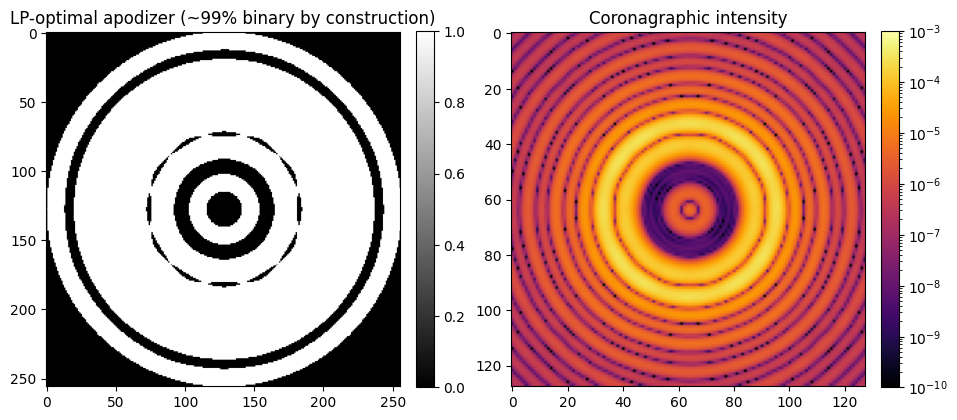

LP design dark-hole max contrast: 1.00e-08 (requirement 1e-08)


In [23]:
pupil.update(x_lp)
I_lp = np.abs(coro.forward(wvl, include_fpm=True)) ** 2 / norm

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].set_title("LP-optimal apodizer (~99% binary by construction)")
im0 = ax[0].imshow(pupil.data, cmap="gray", vmin=0, vmax=1)
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
ax[1].set_title("Coronagraphic intensity")
im1 = ax[1].imshow(I_lp, cmap="inferno", norm=LogNorm(vmin=1e-10, vmax=1e-3))
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
plt.show()

print(f"LP design dark-hole max contrast: {I_lp.ravel()[dh_idx].max():.2e} "
      f"(requirement {contrast_req:.0e})")